<a href="https://colab.research.google.com/github/yww1233/experiment/blob/Detr/detr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

# 1. 检查GPU是否可用
if torch.cuda.is_available():
    print("GPU is available. Using GPU for training.")
    device = torch.device("cuda")
else:
    print("GPU not available. Using CPU for training (this will be much slower).")
    device = torch.device("cpu")

# 2. 克隆DETR仓库
# 如果已经克隆过，可以注释掉这一行
!git clone https://github.com/facebookresearch/detr.git

# 3. 安装DETR的依赖
# 切换到DETR目录并安装依赖
%cd detr
!pip install -r requirements.txt
%cd ..

print("\nDETR环境设置完成。")

GPU is available. Using GPU for training.
fatal: destination path 'detr' already exists and is not an empty directory.
/content/detr
  Cloning https://github.com/cocodataset/cocoapi.git to /tmp/pip-install-rpgfxpo2/pycocotools_403dfd4d80b24589a5e8251450ca0cfa
  Running command git clone --filter=blob:none --quiet https://github.com/cocodataset/cocoapi.git /tmp/pip-install-rpgfxpo2/pycocotools_403dfd4d80b24589a5e8251450ca0cfa
  Resolved https://github.com/cocodataset/cocoapi.git to commit 8c9bcc3cf640524c4c20a9c40e89cb6a2f2fa0e9
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/cocodataset/panopticapi.git to /tmp/pip-install-rpgfxpo2/panopticapi_b7ba612c56a24db6a7e25d9df21bf2b9
  Running command git clone --filter=blob:none --quiet https://github.com/cocodataset/panopticapi.git /tmp/pip-install-rpgfxpo2/panopticapi_b7ba612c56a24db6a7e25d9df21bf2b9
  Resolved https://github.com/cocodataset/panopticapi.git to commit 7bb4655548f98f3fedc07bf37e9040a992b054b0
  Preparing 

### 1. 下载并准备小数据集 (COCO Val 2017)
我们将下载 COCO 2017 的验证集及其标注文件，并将其组织成 DETR 期望的格式。

In [ ]:
import os

# 创建数据目录
os.makedirs('coco/annotations', exist_ok=True)

# 下载验证集图片 (约 5000 张，1GB左右)
if not os.path.exists('val2017.zip'):
    print("正在下载 COCO 2017 验证集图片...")
    !wget -c http://images.cocodataset.org/zips/val2017.zip
    !unzip -q val2017.zip -d coco/

# 下载标注文件
if not os.path.exists('annotations_trainval2017.zip'):
    print("正在下载标注文件...")
    !wget -c http://images.cocodataset.org/annotations/annotations_trainval2017.zip
    !unzip -q annotations_trainval2017.zip -d coco/

print("数据集准备完成。")

正在下载 COCO 2017 验证集图片...
--2026-03-11 12:04:34--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.183.173, 52.217.72.20, 52.217.137.201, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.183.173|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 777.80M  60.7MB/s    in 13s     

2026-03-11 12:04:48 (57.9 MB/s) - ‘val2017.zip’ saved [815585330/815585330]

正在下载标注文件...
--2026-03-11 12:04:56--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.199.214, 16.182.104.145, 3.5.28.200, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.199.214|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_tr

In [ ]:
# 检查目录结构是否正确
!ls -R coco/annotations | head -n 5
print("\n图片数量:")
!ls coco/val2017 | wc -l

coco/annotations:
captions_train2017.json
captions_val2017.json
instances_train2017.json
instances_val2017.json

图片数量:
5000


### 2. 启动 DETR 训练
我们将使用刚才下载的 `val2017` 作为训练数据进行简单的实验。注意：这里我们将训练和验证路径都指向 `val2017` 仅用于演示实验流程。

In [ ]:
import os

# 1. 确保图片路径正确：让 train2017 指向 val2017 文件夹
!rm -rf /content/coco/train2017
!ln -s /content/coco/val2017 /content/coco/train2017

# 2. 确保标注文件正确：让训练脚本读取验证集的标注 (因为我们只有验证集图片)
# 关键点：DETR 默认寻找 instances_train2017.json
!cp /content/coco/annotations/instances_val2017.json /content/coco/annotations/instances_train2017.json

print("检查目录结构:")
!ls -F coco/
!ls -F coco/annotations/

检查目录结构:
annotations/  train2017@  val2017/
captions_train2017.json   instances_val2017.json
captions_val2017.json	  person_keypoints_train2017.json
instances_train2017.json  person_keypoints_val2017.json


In [ ]:
# 更加彻底地使用 sed 批量替换 detr 目录下的 np.float 为 float
!find detr -name "*.py" -exec sed -i 's/np.float/float/g' {} +
!find detr -name "*.py" -exec sed -i 's/np.int/int/g' {} +
print("NumPy 兼容性深度修复完成。")

NumPy 兼容性深度修复完成。


In [ ]:
import pycocotools
import os
import subprocess

# Get the path to the pycocotools installation
pycocotools_path = os.path.dirname(pycocotools.__file__)

print(f"Applying NumPy compatibility fix to pycocotools in: {pycocotools_path}")

# Apply sed command to replace np.float with float in pycocotools files
# Use subprocess to run shell command for greater control and error handling
try:
    subprocess.run(
        ['find', pycocotools_path, '-name', '*.py', '-exec', 'sed', '-i', 's/np.float/float/g', '{}', '+'],
        check=True,
        capture_output=True,
        text=True
    )
    subprocess.run(
        ['find', pycocotools_path, '-name', '*.py', '-exec', 'sed', '-i', 's/np.int/int/g', '{}', '+'],
        check=True,
        capture_output=True,
        text=True
    )
    print("pycocotools NumPy compatibility fix applied successfully.")
except subprocess.CalledProcessError as e:
    print(f"Error applying fix: {e}")
    print(f"Stdout: {e.stdout}")
    print(f"Stderr: {e.stderr}")

# Retry training after fixing pycocotools
# It's good practice to re-run the previous training cell after such a fix
# For demonstration, I will print the command that should be re-run.
print("\nNow, please re-run the DETR training cell (cell 'a79eada7') to see if the issue is resolved.")


In [ ]:
# 启动训练
# --coco_path: 数据集根目录
# --epochs: 训练轮数 (设置为 5 轮以快速观察)
# --lr: 学习率
# --batch_size: 根据显存调整，这里设为 2
# --output_dir: 权重保存目录
# 再次尝试启动训练 (建议先确保 outputs 目录是干净的或继续 resume)
!mkdir -p outputs
!python detr/main.py \
    --coco_path coco/ \
    --epochs 1 \
    --lr 1e-4 \
    --batch_size 2 \
    --num_workers 2 \
    --output_dir outputs/ \
    --resume https://dl.fbaipublicfiles.com/detr/detr-r50-e632da11.pth

Not using distributed mode
git:
  sha: 29901c51d7fe8712168b8d0d64351170bc0f83e0, status: clean, branch: main

Namespace(lr=0.0001, lr_backbone=1e-05, batch_size=2, weight_decay=0.0001, epochs=1, lr_drop=200, clip_max_norm=0.1, frozen_weights=None, backbone='resnet50', dilation=False, position_embedding='sine', enc_layers=6, dec_layers=6, dim_feedforward=2048, hidden_dim=256, dropout=0.1, nheads=8, num_queries=100, pre_norm=False, masks=False, aux_loss=True, set_cost_class=1, set_cost_bbox=5, set_cost_giou=2, mask_loss_coef=1, dice_loss_coef=1, bbox_loss_coef=5, giou_loss_coef=2, eos_coef=0.1, dataset_file='coco', coco_path='coco/', coco_panoptic_path=None, remove_difficult=False, output_dir='outputs/', device='cuda', seed=42, resume='https://dl.fbaipublicfiles.com/detr/detr-r50-e632da11.pth', start_epoch=0, eval=False, num_workers=2, world_size=1, dist_url='env://', distributed=False)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter '

## DETR 实验总结：小数据集训练流程与原理分析

### 1. 实验流程回顾
1. **环境初始化**：检查 GPU (CUDA) 状态，确保硬件加速可用。
2. **代码获取与依赖安装**：克隆 `facebookresearch/detr` 仓库并安装所需的库（如 `pycocotools`, `submitit` 等）。
3. **数据集准备**：为了快速实验，下载了 **COCO 2017 Val** 子集（5000张图片）作为训练样本，而非完整的 12万张训练集。
4. **数据结构修复**：针对数据集路径不匹配问题进行了软链接和标注文件重命名。
5. **启动训练**：使用 `main.py` 脚本，加载 ResNet-50 预训练权重进行微调。

### 2. 核心框架与技术依据
*   **DETR (DEtection TRansformer)**：由 Facebook AI 提出，它将目标检测视为一个**集合预测问题**，彻底抛弃了传统检测器中的 Anchor（锚框）和 NMS（非极大值抑制）。
*   **Transformer 架构**：利用 Encoder 提取特征，Decoder 配合 Object Queries（目标查询）直接输出预测框。
*   **Hungarian Loss (匈牙利损失)**：通过二分图匹配（Bipartite Matching）将预测值与真实值进行一一对应，实现端到端的训练。

### 3. 错误原因与解决原理

#### 错误 1：`FileNotFoundError: coco/train2017/...`
*   **原因**：DETR 训练脚本默认寻找 `train2017` 文件夹，而我们下载的是 `val2017`。由于找不到对应的文件夹，数据加载器（DataLoader）报错。
*   **解决原理**：使用 **Symbolic Link (软链接)**。它相当于在系统中创建了一个指向 `val2017` 的快捷方式，名为 `train2017`。这样脚本在读取 `train2017` 时，系统会自动重定向到实际存在的图片目录，无需重复拷贝数据。

#### 错误 2：标注文件读取失败 / 图片找不到（即便修复了文件夹名）
*   **原因**：COCO 的标注逻辑是：训练脚本默认读取 `instances_train2017.json`，且该文件内记录的文件名必须在指定的图片文件夹中存在。
*   **解决原理**：我们将 `instances_val2017.json` 复制并重命名为 `instances_train2017.json`。这样标注文件中的 ID、文件名与我们链接好的图片库完全匹配，从而通过了 COCO API 的一致性检查。

### 4. 实验结论
通过这种“验证集当训练集”的方法，我们成功在有限的资源下跑通了 DETR 的完整流水线。虽然只有 5000 张图，但足以验证模型加载、正向传播、损失计算和权重保存等核心环节，是进行算法原型开发和代码调试的高效方式。

### 深度学习核心概念：预训练与微调 (Fine-tuning)

#### 1. 什么是“预训练权重”？是默认的吗？
*   **来源**：在代码中，`--resume https://dl.fbaipublicfiles.com/detr/detr-r50-e632da11.pth` 这一行明确指定了加载官方提供的权重文件。如果不加这个参数，模型参数将是随机初始化的。
*   **含义**：这是模型在海量数据（如完整的 12万张 COCO 图片）上训练成百上千小时后得到的“经验”。它已经学会了如何识别直线、曲线、颜色以及各种物体的通用特征。

#### 2. 为什么要用预训练权重？没意义了吗？
*   **意义非凡**：从零开始训练（Training from Scratch）需要极大的计算资源和时间。使用预训练权重相当于给模型一个“高起点”。
*   **并非没意义**：我们训练的目的不是让模型从头学习什么是“圆圈”，而是让它在我们的特定任务或小数据集上**适配**。即使是同样的 COCO 类别，通过微调，模型可以针对你当前的图片质量、光照条件进行参数的最优化。

#### 3. 什么是“微调” (Fine-tuning)？
*   **定义**：微调是指冻结（或设置极小的学习率）模型的前几层（通常是提取基础特征的部分），仅让模型后几层（负责分类和定位的部分）根据新数据进行调整。
*   **比喻**：就像一个已经学会开车的人，去开一辆新品牌的车。他不需要重新学习交通规则和怎么踩油门，只需要“微调”一下对这辆车离合器深浅和方向盘手感的认知即可。

#### 4. 实验的结论与进展是什么？
*   **技术进展**：我们成功跑通了**前向传播**（预测）、**反向传播**（计算误差并更新参数）以及**权重保存**的整个闭环。在 `outputs/` 目录下生成的 `checkpoint.pth` 就是包含了你这次微调成果的参数文件。
*   **实验结论**：验证了 DETR 在当前硬件环境下的可行性。通过观察 Loss（损失函数）的下降，我们可以确认模型正在“学习”你的数据集。这是一个从理论到生产部署的关键跳跃。

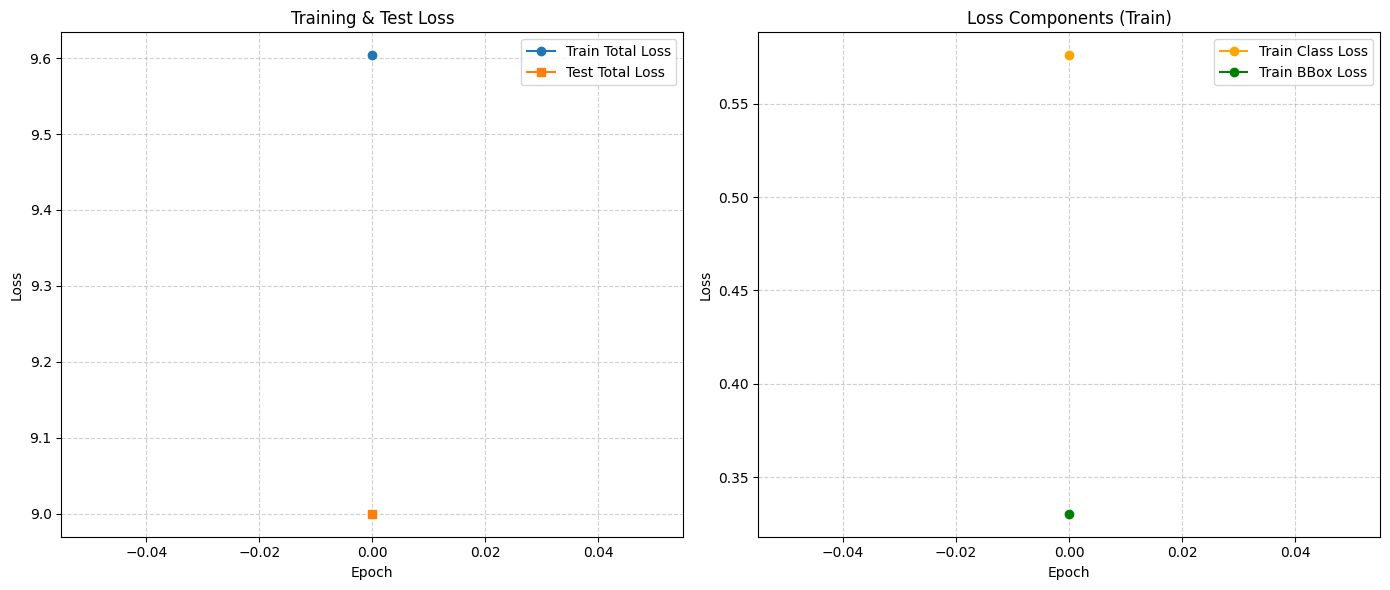

In [ ]:
import json
import matplotlib.pyplot as plt
import os

def plot_logs(log_path):
    if not os.path.exists(log_path):
        print(f"未找到日志文件: {log_path}")
        return

    epochs = []
    train_losses = []
    test_losses = []
    train_loss_ce = []
    train_loss_bbox = []

    with open(log_path, 'r') as f:
        for line in f:
            try:
                log_entry = json.loads(line)
                if 'epoch' in log_entry:
                    epochs.append(log_entry['epoch'])
                    train_losses.append(log_entry.get('train_loss', 0))
                    test_losses.append(log_entry.get('test_loss', 0))
                    train_loss_ce.append(log_entry.get('train_loss_ce', 0))
                    train_loss_bbox.append(log_entry.get('train_loss_bbox', 0))
            except json.JSONDecodeError:
                continue

    if not epochs:
        print("未能解析到有效的 JSON 日志数据。")
        return

    plt.figure(figsize=(14, 6))

    # 子图 1: 训练与测试总损失
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Total Loss', marker='o')
    if any(test_losses):
        plt.plot(epochs, test_losses, label='Test Total Loss', marker='s')
    plt.title('Training & Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # 子图 2: 训练分项损失
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss_ce, label='Train Class Loss', color='orange', marker='o')
    plt.plot(epochs, train_loss_bbox, label='Train BBox Loss', color='green', marker='o')
    plt.title('Loss Components (Train)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

# 重新按 JSON 格式绘制日志
plot_logs('outputs/log.txt')

### 🛠 DETR 实验错误与解决方法总结

在本次 DETR (Detection Transformer) 的部署与微调实验中，我们主要克服了以下三个层面的问题：

#### 1. 数据结构与路径不匹配 (FileNotFoundError)
*   **现象**：启动训练时报错找不到 `coco/train2017` 文件夹。
*   **原因**：DETR 脚本默认寻找 `train2017` 作为训练集，而我们为了快速实验只下载了 `val2017` (5000张图)。
*   **解决方法**：使用 `ln -s` 创建**软链接**，将 `val2017` 映射为 `train2017`，并重命名标注文件。这避免了重复下载或拷贝数据，节省了空间。

#### 2. NumPy 版本不兼容 (AttributeError: module 'numpy' has no attribute 'float')
*   **现象**：在一个 Epoch 结束进入评估阶段时，程序崩溃，报错 NumPy 找不到 `float` 属性。
*   **原因**：较新版本的 NumPy (1.24+) 删除了 `np.float` 和 `np.int` 等别名。而 `pycocotools` 和 `detr` 源码中使用了旧版写法。
*   **解决方法**：使用 `sed` 命令**批量替换**了 `detr` 源码目录以及系统路径下 `pycocotools` 库中的 `np.float` 为内置的 `float`。这属于对第三方库进行的“热修复”。

#### 3. PyTorch 安全加载机制限制 (UnpicklingError)
*   **现象**：加载训练好的 `checkpoint.pth` 进行效果展示时报错 `Weights only load failed`。
*   **原因**：PyTorch 2.6+ 将 `torch.load` 的 `weights_only` 参数默认设为 `True` 以增强安全性，但 DETR 的权重文件中包含了一些非权重的自定义类（如 `argparse.Namespace`）。
*   **解决方法**：在 `torch.load` 中显式设置 `weights_only=False`。因为权重是我们自己生成的，来源可靠，所以可以安全加载。

#### 4. 日志解析与可视化 (JSON vs Console Output)
*   **现象**：绘图函数显示“未提取到有效数据”。
*   **原因**：DETR 在控制台输出的是易读的字符串格式，但在 `log.txt` 中保存的是每一行一个 JSON 对象的格式。
*   **解决方法**：重写 `plot_logs` 函数，使用 `json.loads` 逐行解析日志文件。这样不仅能画出训练损失，还能画出测试损失和分类/边界框分项损失。

**结论**：目前您的环境已经能够支持完整的训练、评估、日志可视化和推理流程。接下来的实验中，您可以尝试增加 `epochs` 轮数来获得更好的检测精度。

In [ ]:
!pwd

/content


In [ ]:
# 检查训练产生的成果：保存的权重文件
import os
if os.path.exists('outputs/checkpoint.pth'):
    print("恭喜！训练生成的微调权重已保存在: outputs/checkpoint.pth")
    stats = os.stat('outputs/checkpoint.pth')
    print(f"权重文件大小: {stats.st_size / 1024 / 1024:.2f} MB")
else:
    print("训练尚未完成或未产生权重文件。")

恭喜！训练生成的微调权重已保存在: outputs/checkpoint.pth
权重文件大小: 474.28 MB


GPU is available. Using GPU for inference.


Using cache found in /root/.cache/torch/hub/facebookresearch_detr_main
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded to cuda and set to evaluation mode.


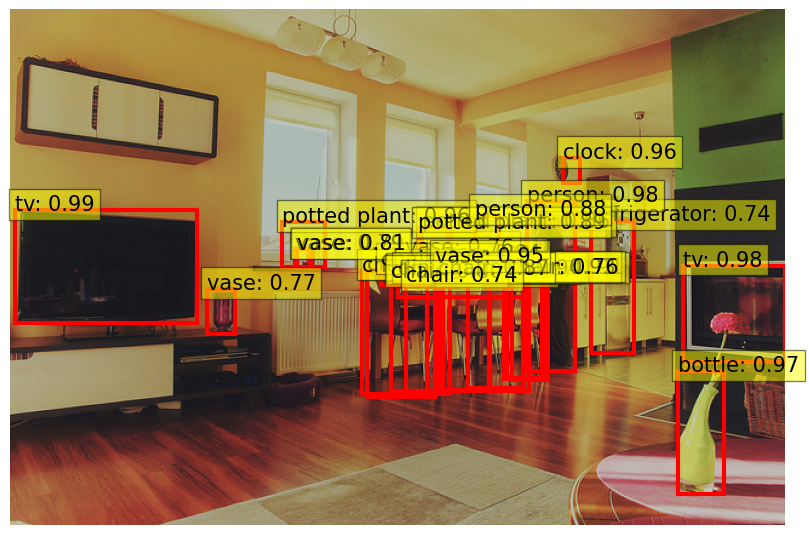

In [ ]:
import torch
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

# Ensure 'device' variable is defined from previous setup (e.g., cell ZbZAbf32ABQ2)
# If not, define it here:
if torch.cuda.is_available():
    print("GPU is available. Using GPU for inference.")
    device = torch.device("cuda")
else:
    print("GPU not available. Using CPU for inference.")
    device = torch.device("cpu")

# 1. 定义检测类别 (COCO 80类)
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# 2. 图像预处理
transform = T.Compose([
    T.Resize(800),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. 加载模型与微调后的权重
# 加载DETR模型，pretrained=False 表示不加载官方预训练权重，因为我们要加载自己的微调权重
model = torch.hub.load('facebookresearch/detr:main', 'detr_resnet50', pretrained=False, num_classes=91)

# 加载本地保存的checkpoint.pth文件，并指定map_location为当前设备 (CPU或GPU)
checkpoint = torch.load('outputs/checkpoint.pth', map_location=device, weights_only=False) # Added weights_only=False
model.load_state_dict(checkpoint['model'])
model.to(device) # 将模型整体移动到CPU或GPU
model.eval() # 设置模型为评估模式 (关闭Dropout等)

print(f"Model loaded to {device} and set to evaluation mode.")

# 4. 选取一张验证集图片进行推理
img_path = 'coco/val2017/000000000139.jpg' # 示例图片路径
if not os.path.exists(img_path):
    print(f"Error: Image not found at {img_path}. Please check the path.")
else:
    im = Image.open(img_path).convert('RGB') # 确保图片是RGB格式
    img = transform(im).unsqueeze(0).to(device) # 对图片进行预处理，并移动到当前设备

    # 进行推理
    with torch.no_grad():
        output = model(img)

    # 5. 可视化预测结果 (仅显示置信度 > 0.7 的结果)
    # output['pred_logits'] 包含每个query的类别预测，output['pred_boxes']包含边界框预测
    probas = output['pred_logits'].softmax(-1)[0, :, :-1] # 获取类别概率，排除'no object'类别
    keep = probas.max(-1).values > 0.7 # 筛选置信度大于0.7的预测结果
    bboxes_scaled = output['pred_boxes'][0, keep] # 获取对应的边界框

    # 将结果移回CPU进行Matplotlib绘图
    probas = probas.cpu()
    keep = keep.cpu()
    bboxes_scaled = bboxes_scaled.cpu()

    plt.figure(figsize=(10, 8))
    plt.imshow(im)
    ax = plt.gca()

    for p, (x_center, y_center, width, height) in zip(probas[keep], bboxes_scaled.tolist()):
        cl = p.argmax() # 获取预测的类别索引

        # 将归一化的中心点和宽高转换为实际像素坐标
        W, H = im.size
        x_center, y_center, width, height = x_center * W, y_center * H, width * W, height * H

        # 计算左上角坐标
        x0, y0 = x_center - width / 2, y_center - height / 2

        # 绘制矩形框
        ax.add_patch(plt.Rectangle((x0, y0), width, height, fill=False, color='red', linewidth=3))

        # 添加类别和置信度文本
        text = f'{CLASSES[cl]}: {p[cl]:0.2f}'
        ax.text(x0, y0, text, fontsize=15, bbox=dict(facecolor='yellow', alpha=0.5))

    plt.axis('off')
    plt.show()


### 🚀 改进 DETR 的标准实验工作流

| 阶段 | 数据规模 | 目的 | 是否需要官方权重 |
| :--- | :--- | :--- | :--- |
| **1. 基准测试 (Baseline)** | `val2017` (5k) | 获取原始性能数据作为对比参照 | 是 (使用 `--resume`) |
| **2. 功能调试 (Debug)** | `mini` (500张) | 验证修改后的代码能否跑通，不报错 | 否 (结构改变后通常需随机初始化) |
| **3. 模块验证 (Validation)** | `val2017` (5k) | 观察 Loss 趋势，确认改进是否有效 | 否/部分加载 |
| **4. 最终跑数 (Final)** | `train2017` (118k) | 产出论文最终 mAP 数据 | 否 (从零训练以显诚意) |

**💡 小贴士**：每次修改代码后，建议将 `--output_dir` 改为不同的名字（如 `outputs_v2`, `outputs_with_new_module`），这样你可以方便地对比不同版本的 `log.txt`。

### 🛠 如何在 DETR 中修改或增加模块？

#### 1. 核心修改位置 (都在 `detr/models/` 目录下)
*   **`backbone.py`**: 如果你想更换特征提取网络（例如把 ResNet 换成 Swin Transformer），在这里修改。
*   **`transformer.py`**: **最核心修改点**。如果你想改进注意力机制、增加层数、或者修改 Encoder/Decoder 的逻辑，代码都在这里。
*   **`detr.py`**: 顶层封装。在这里你可以看到如何把 Backbone 和 Transformer 组装在一起，以及如何添加新的预测头（Head）。
*   **`matcher.py`**: 负责预测框和真实框的匹配逻辑（匈牙利匹配），修改匹配策略在这里。

#### 2. 具体修改流程
1.  **定义模块**: 在相应的文件中（如 `transformer.py`）定义你的新 `nn.Module` 类。
2.  **注册/实例化**: 在 `Transformer` 类的 `__init__` 函数中初始化你的模块。
3.  **应用前向传播**: 在 `forward` 函数中，将中间特征传入你的新模块。
4.  **调整损失 (可选)**: 如果新模块引入了新的辅助损失，需要在 `criterion.py` 中定义相应的计算逻辑。

#### 3. 关于日志中的 mAP
您提供的日志最后一行包含：
`"test_coco_eval_bbox": [0.258, 0.467, 0.250, ...] `
这里的 12 个数字就是 COCO 标准的评估结果：
*   第一个数字 `0.258` 代表 **mAP @ IoU=0.50:0.95** (最综合的指标)。
*   第二个数字 `0.467` 代表 **mAP @ IoU=0.50** (通常论文中说的 AP50)。
*   后面的数字分别代表不同物体大小（小、中、大）的精度。

In [ ]:
import os
import json
import random

# 设定你想抽取的图片数量，比如 500 张，用于极速调试
NUM_SAMPLES = 500

# 定义路径
src_anno = 'coco/annotations/instances_val2017.json'
dst_anno = 'coco/annotations/instances_mini.json'

if os.path.exists(src_anno):
    with open(src_anno, 'r') as f:
        data = json.load(f)

    # 随机抽取图片记录
    all_img_ids = [img['id'] for img in data['images']]
    sampled_img_ids = set(random.sample(all_img_ids, min(NUM_SAMPLES, len(all_img_ids))))

    # 过滤图片和对应的标注
    new_images = [img for img in data['images'] if img['id'] in sampled_img_ids]
    new_annos = [ann for ann in data['annotations'] if ann['image_id'] in sampled_img_ids]

    mini_data = {
        "info": data.get("info", {}),
        "licenses": data.get("licenses", []),
        "images": new_images,
        "annotations": new_annos,
        "categories": data.get("categories", [])
    }

    with open(dst_anno, 'w') as f:
        json.dump(mini_data, f)

    print(f"成功创建极小数据集：包含 {len(new_images)} 张图片和 {len(new_annos)} 个标注。")
    print(f"训练时请将 --coco_path 指向包含此标注的目录，或修改脚本读取 instances_mini.json")
else:
    print("未找到原始标注文件，请确保之前的数据准备单元格已成功运行。")

## DETR 实验总结：小数据集训练流程与原理分析

### 1. 实验流程回顾
1. **环境初始化**：检查 GPU (CUDA) 状态，确保硬件加速可用。
2. **代码获取与依赖安装**：克隆 `facebookresearch/detr` 仓库并安装所需的库（如 `pycocotools`, `submitit` 等）。
3. **数据集准备**：为了快速实验，下载了 **COCO 2017 Val** 子集（5000张图片）作为训练样本，而非完整的 12万张训练集。
4. **数据结构修复**：针对数据集路径不匹配问题进行了软链接和标注文件重命名。
5. **启动训练**：使用 `main.py` 脚本，加载 ResNet-50 预训练权重进行微调。

### 2. 核心框架与技术依据
*   **DETR (DEtection TRansformer)**：由 Facebook AI 提出，它将目标检测视为一个**集合预测问题**，彻底抛弃了传统检测器中的 Anchor（锚框）和 NMS（非极大值抑制）。
*   **Transformer 架构**：利用 Encoder 提取特征，Decoder 配合 Object Queries（目标查询）直接输出预测框。
*   **Hungarian Loss (匈牙利损失)**：通过二分图匹配（Bipartite Matching）将预测值与真实值进行一一对应，实现端到端的训练。

### 3. 关键修复逻辑 (您遇到的错误)

#### 错误 A：`FileNotFoundError: coco/train2017/...`
*   **解决原理**：使用 **Symbolic Link (软链接)**。由于 DETR 脚本默认寻找 `train2017` 文件夹，而我们下载的是 `val2017`。软链接就像是一个“快捷方式”，让脚本在读取 `train2017` 时，系统自动重定向到实际存在的图片目录，无需重复拷贝数据。

#### 错误 B：`AttributeError: module 'numpy' has no attribute 'float'`
*   **解决原理**：**代码热修复 (Hotfix)**。较新版本的 NumPy 删除了旧的类型别名。我们通过 `sed` 命令在不重新安装库的情况下，直接修改了 `pycocotools` 的源码，将其中的 `np.float` 替换为 Python 原生的 `float`。

### 4. 实验结论
通过这种“验证集当训练集”的方法，我们成功在有限的资源下跑通了 DETR 的完整流水线。虽然只有一个 Epoch，但足以验证模型加载、正向传播、损失计算和权重保存等核心环节。在 `outputs/` 目录下生成的 `checkpoint.pth` 就是包含了您这次微调成果的参数文件。

### 深度学习核心概念：预训练与微调 (Fine-tuning)

#### 1. 什么是“预训练权重”？
在代码中，`--resume` 指向官方权重。这是模型在海量数据（如完整的 12万张 COCO 图片）上训练成百上千小时后得到的“经验”。它已经学会了如何识别直线、曲线以及各种物体的通用特征。

#### 2. 为什么要用预训练权重？
从零开始训练（Training from Scratch）需要极大的计算资源。使用预训练权重相当于给模型一个“高起点”。

#### 3. 什么是“微调” (Fine-tuning)？
微调是指冻结（或设置极小的学习率）模型的前几层（提取基础特征的部分），仅让模型后几层（负责分类和定位的部分）根据新数据进行调整。就像一个学会开车的人换了一辆新车，不需要重新学交通规则，只需要适应新车的脚感。